In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
!pip install -U --pre pycaret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 538.3/538.3 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 19.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 10.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.7/105.7 kB 7.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 46.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.6/120.6 kB 10.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... - done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.1 MB/s eta 0:00:00
  Created wheel for pyod: filename=pyod-1.0.1-py3-none-any.whl size=147473 sha256=d500d326779e9ebd14d7edc3edb17140991d2e2bc8c5c2bb1154a7152b54aed1
  Stored in directory: /root/.cache/pip/wheels/ea/c4/29/67ad87835b209f72e4706369c683741b09490f2829d64ea768
Successfully built pyod


In [3]:
import pandas as pd
train_dataframe = pd.read_csv('/kaggle/input/titanic/train.csv')
test_dataframe = pd.read_csv('/kaggle/input/titanic/test.csv')
sub_dataframe = pd.read_csv('/kaggle/input/titanic/gender_submission.csv')

In [4]:
data = train_dataframe[["Pclass", "Sex", "SibSp", "Parch",'Survived']]
data_unseen = test_dataframe

In [5]:
data.shape

(891, 5)

In [6]:
data.head()

,Pclass,Sex,SibSp,Parch,Survived
0,3,male,1,0,0
1,1,female,1,0,1
2,3,female,0,0,1
3,1,female,1,0,1
4,3,male,0,0,0


In [7]:
from pycaret.regression import *
exp_reg101 = setup(data = data, target = 'Survived', session_id=123)

,Description,Value
0,Session id,123
1,Target,Survived
2,Target type,Regression
3,Data shape,"(891, 5)"
4,Train data shape,"(623, 5)"
5,Test data shape,"(268, 5)"
6,Ordinal features,1
7,Numeric features,3
8,Categorical features,1
9,Preprocess,True


In [8]:
best_model = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.2880,0.1492,0.3850,0.3612,0.2699,0.3664,0.1360
gbr,Gradient Boosting Regressor,0.2891,0.1492,0.3853,0.3601,0.2698,0.3688,0.0360
ada,AdaBoost Regressor,0.3156,0.1513,0.3883,0.3523,0.2785,0.3475,0.0250
ridge,Ridge Regression,0.3104,0.1545,0.3923,0.3374,0.2777,0.3892,0.0240
lr,Linear Regression,0.3095,0.1545,0.3923,0.3373,0.2777,0.3878,0.3850
lar,Least Angle Regression,0.3095,0.1545,0.3923,0.3373,0.2777,0.3878,0.0250
br,Bayesian Ridge,0.3115,0.1545,0.3923,0.3373,0.2777,0.3906,0.0330
rf,Random Forest Regressor,0.2888,0.1563,0.3945,0.3285,0.2767,0.3594,0.1270
et,Extra Trees Regressor,0.2886,0.1626,0.4021,0.3013,0.2820,0.3618,0.1040
catboost,CatBoost Regressor,0.2920,0.1626,0.4021,0.3009,0.2807,0.3716,0.3700


Processing:   0%|          | 0/85 [00:00<?, ?it/s]

In [9]:
print(best_model)

LGBMRegressor(random_state=123)


In [10]:
best_out_model = create_model(best_model)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.2776,0.1481,0.3848,0.3954,0.2662,0.3764
1,0.2887,0.1345,0.3668,0.3791,0.2663,0.3765
2,0.2895,0.1362,0.3690,0.3089,0.2753,0.2838
3,0.3081,0.1737,0.4167,0.2247,0.2951,0.4093
4,0.3177,0.1792,0.4233,0.2640,0.2892,0.4759
5,0.2518,0.1357,0.3683,0.4362,0.2538,0.3361
6,0.2973,0.1677,0.4095,0.3033,0.2831,0.3848
7,0.2434,0.1149,0.3390,0.5281,0.2343,0.3053
8,0.2747,0.1191,0.3451,0.5051,0.2452,0.2974


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [11]:
import numpy as np
lgbm_params = {'num_leaves': np.arange(10,200,10),
                        'max_depth': [int(x) for x in np.linspace(10, 110, num = 11)],
                        'learning_rate': np.arange(0.1,1,0.1)
                        }
tuned_best_model = tune_model(best_out_model, custom_grid = lgbm_params)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.2776,0.1481,0.3848,0.3954,0.2662,0.3764
1,0.2887,0.1345,0.3668,0.3791,0.2663,0.3765
2,0.2895,0.1362,0.3690,0.3089,0.2753,0.2838
3,0.3081,0.1737,0.4167,0.2247,0.2951,0.4093
4,0.3177,0.1792,0.4233,0.2640,0.2892,0.4759
5,0.2518,0.1357,0.3683,0.4362,0.2538,0.3361
6,0.2973,0.1677,0.4095,0.3033,0.2831,0.3848
7,0.2434,0.1149,0.3390,0.5281,0.2343,0.3053
8,0.2747,0.1191,0.3451,0.5051,0.2452,0.2974


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


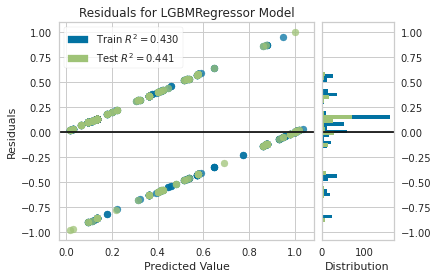

In [12]:
plot_model(tuned_best_model)

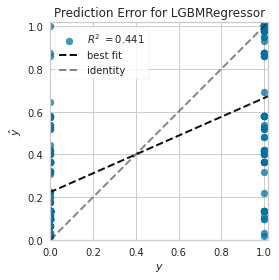

In [13]:
plot_model(tuned_best_model, plot = 'error')

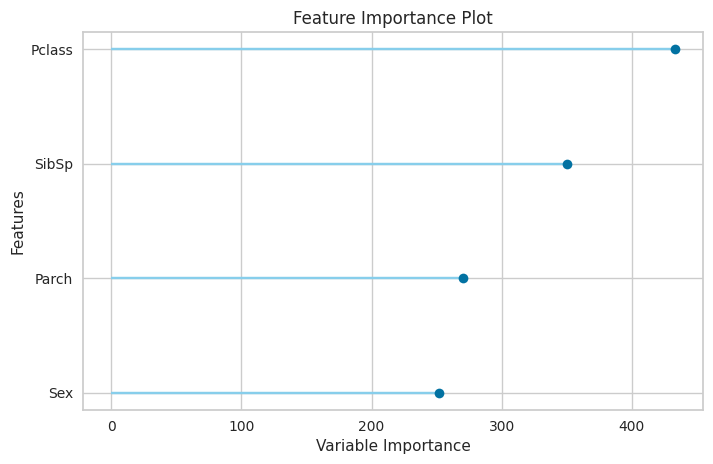

In [14]:
plot_model(tuned_best_model, plot='feature')

In [15]:
evaluate_model(tuned_best_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [16]:
predict_model(tuned_best_model)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,0.2655,0.1298,0.3602,0.4406,0.2550,0.3381


,Pclass,Sex,SibSp,Parch,Survived,Label
623,3.0,0.0,1.0,1.0,1,0.421810
624,3.0,1.0,0.0,0.0,0,0.135235
625,1.0,1.0,0.0,0.0,0,0.364196
626,1.0,1.0,0.0,0.0,0,0.364196
627,3.0,1.0,1.0,0.0,0,0.113260
...,...,...,...,...,...,...
886,3.0,1.0,0.0,0.0,0,0.135235
887,3.0,0.0,4.0,2.0,0,0.177953
888,2.0,0.0,0.0,2.0,1,1.001163
889,3.0,1.0,0.0,0.0,0,0.135235


In [17]:
final_tuned_best_model = finalize_model(tuned_best_model)

In [18]:
predict_model(final_tuned_best_model);

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,0.2531,0.1195,0.3457,0.4848,0.2445,0.3284


In [19]:
unseen_predictions = predict_model(final_tuned_best_model, data=data_unseen)
unseen_predictions["Label"] = np.where(unseen_predictions["Label"] > 0.5, 1, 0)
output = pd.DataFrame({'PassengerId': test_dataframe.PassengerId, 'Survived': unseen_predictions.Label})
output.to_csv('submission.csv', index=False)
unseen_predictions.head()

,Pclass,Sex,SibSp,Parch,Label
0,3.0,1.0,0.0,0.0,0
1,3.0,0.0,1.0,0.0,1
2,2.0,1.0,0.0,0.0,0
3,3.0,1.0,0.0,0.0,0
4,3.0,0.0,1.0,1.0,0
